In [ ]:
import subprocess
import sys

# Crear un entorno virtual llamado 'venv'
subprocess.check_call([sys.executable, "-m", "venv", "venv"])
print("Entorno virtual creado correctamente")

✅ Entorno virtual creado correctamente


# 📊 Evaluación Semántica de Pictogramas


# 1. Instalación y dependencias

In [2]:
# Instalación de dependencias
%pip install sacrebleu scipy scikit-learn matplotlib seaborn pandas numpy krippendorff -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import subprocess, sys
packages = ["sacrebleu", "scipy", "scikit-learn", "matplotlib", "seaborn", "pandas"]
for pkg in packages:
 subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("Dependencias instaladas correctamente")

✅ Dependencias instaladas correctamente


In [ ]:
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sacrebleu.metrics import BLEU, CHRF
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')
# Estilo visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")
print("Imports correctos")

✅ Imports correctos


# 2. Carga de datos

In [ ]:
# ─────────────────────────────────────────────────────────────────
# AJUSTA ESTA RUTA a donde tengas tus archivos de datos
# ─────────────────────────────────────────────────────────────────
DATA_DIR = "data" # ← carpeta data/ está un nivel arriba de notebooks/

def load_json(filename):
    path = os.path.join(DATA_DIR, filename)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

# Dataset principal
train_data = load_json("train.json")
test_data = load_json("test (2).json")
val_data = load_json("validation.json")

# Predicciones de los 4 modelos
modelo1 = load_json("modelo1.json")
modelo2 = load_json("modelo2.json")
modelo3 = load_json("modelo3.json")
modelo4 = load_json("modelo4.json")

# IDs de pictogramas válidos
with open(os.path.join(DATA_DIR, "ids_only_id.txt"), "r") as f:
    valid_pict_ids = set(line.strip() for line in f.readlines())

# Evaluaciones humanas
EVALUATOR_FILES = [
    "respuestas_a.paredes.um@gmail.com",
    "respuestas_angela.mariategui@gmail.com",
    "respuestas_CUSIPAUCARALACANTARAGMAIL.COM",
    "respuestas_humansanchezmayra@gmail.com",
    "respuestas_ilivaldez@hotmail.com",
    "respuestas_k.leyvarivera@gmail.com",
    "respuestas_norka.bringas@gmail.com",
    "respuestas_psico.espinoza18@gmail.com",
]
evaluations = [] 

for fname in EVALUATOR_FILES:
    path = os.path.join(DATA_DIR, fname)
    with open(path, "r", encoding="utf-8") as f:
        evaluations.append(json.load(f))

print(f"train: {len(train_data):,} ejemplos")
print(f"test: {len(test_data):,} ejemplos")
print(f"val: {len(val_data):,} ejemplos")
print(f"IDs de pictogramas válidos: {len(valid_pict_ids):,}")
print(f"Modelos cargados: {len(modelo1)} predicciones c/u")
print(f"Evaluadores humanos: {len(evaluations)}")


✅ train: 15,208 ejemplos
✅ test: 973 ejemplos
✅ val: 973 ejemplos
✅ IDs de pictogramas válidos: 13,515
✅ Modelos cargados: 50 predicciones c/u
✅ Evaluadores humanos: 8


In [6]:
# Crear diccionarios indexados por id para acceso rápido
test_by_id = {x["id"]: x for x in test_data}
model1_by_id = {x["id"]: x for x in modelo1}
model2_by_id = {x["id"]: x for x in modelo2}
model3_by_id = {x["id"]: x for x in modelo3}
model4_by_id = {x["id"]: x for x in modelo4}
# IDs evaluados (50 ejemplos)
EVAL_IDS = sorted(model1_by_id.keys())
print(f"IDs evaluados: {EVAL_IDS[:5]}...{EVAL_IDS[-5:]} (total: {len(EVAL_IDS)})")

IDs evaluados: [0, 1, 2, 3, 4]...[968, 969, 970, 971, 972] (total: 50)


# 3. Análisis exploratorio del dataset

In [7]:
# ── Estadísticas básicas del corpus ──────────────────────────────
def token_stats(data, field="oracion"):
    lengths = [len(x[field].split()) for x in data if field in x]
    return {
        "n": len(lengths),
        "min": min(lengths),
        "max": max(lengths),
        "mean": round(np.mean(lengths), 2),
        "std": round(np.std(lengths), 2),
        "median": int(np.median(lengths))
}

def pict_stats(data, field="traduccion"):
    lengths = [len(x[field].split()) for x in data if field in x]
    return {
        "n": len(lengths),
        "min": min(lengths),
        "max": max(lengths),
        "mean": round(np.mean(lengths), 2),
        "std": round(np.std(lengths), 2),
        "median": int(np.median(lengths))
}

splits = {"train": train_data, "test": test_data, "validation": val_data}
stats_rows = []
for name, data in splits.items():
    ts = token_stats(data, "oracion")
    ps = pict_stats(data, "traduccion")
    stats_rows.append({
        "Split": name,
        "N ejemplos": ts["n"],
        "Tokens/frase (media)": ts["mean"],
        "Tokens/frase (max)": ts["max"],
        "Pictogramas/ref (media)": ps["mean"],
        "Pictogramas/ref (max)": ps["max"],
})
    
df_stats = pd.DataFrame(stats_rows)
print("=== Estadísticas del corpus ===")
print(df_stats.to_string(index=False))

=== Estadísticas del corpus ===
     Split  N ejemplos  Tokens/frase (media)  Tokens/frase (max)  Pictogramas/ref (media)  Pictogramas/ref (max)
     train       15208                  4.76                  15                     3.91                     14
      test         973                  5.09                  22                     3.15                     11
validation         973                  4.99                  21                     3.08                     11


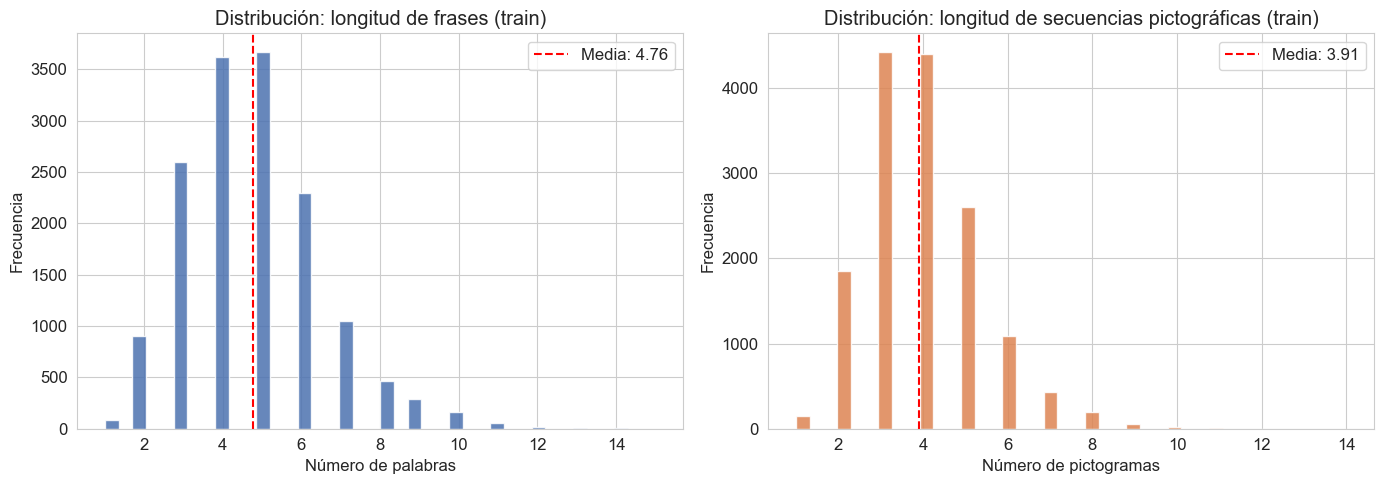

✅ Gráfico guardado: dist_longitudes.png


In [ ]:
# ── Distribución de longitudes en train ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

oracion_lens = [len(x["oracion"].split()) for x in train_data]
pict_lens = [len(x["traduccion"].split()) for x in train_data]

# Gráfico 1: oraciones
axes[0].hist(oracion_lens, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribución: longitud de frases (train)")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(
    np.mean(oracion_lens),
    color="red",
    linestyle="--",
    label=f"Media: {np.mean(oracion_lens):.2f}"
)
axes[0].legend()

# Gráfico 2: pictogramas
axes[1].hist(pict_lens, bins=40, color="#DD8452", edgecolor="white", alpha=0.85)
axes[1].set_title("Distribución: longitud de secuencias pictográficas (train)")
axes[1].set_xlabel("Número de pictogramas")
axes[1].set_ylabel("Frecuencia")
axes[1].axvline(
    np.mean(pict_lens),
    color="red",
    linestyle="--",
    label=f"Media: {np.mean(pict_lens):.2f}"
)
axes[1].legend()

plt.tight_layout()
plt.savefig("dist_longitudes.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico guardado: dist_longitudes.png")

=== Top 20 pictogramas más frecuentes (train) ===
Pictograma  Frecuencia
 pict_3047        2192
 pict_7029        1858
 pict_2627        1698
pict_22624        1515
 pict_5581        1132
pict_37340         784
 pict_6481         760
pict_11749         668
pict_15485         646
 pict_2380         630
 pict_7141         581
pict_22619         576
 pict_3345         511
 pict_9870         441
pict_11351         420
 pict_2474         399
 pict_7095         362
pict_12281         348
 pict_7271         337
 pict_7217         317


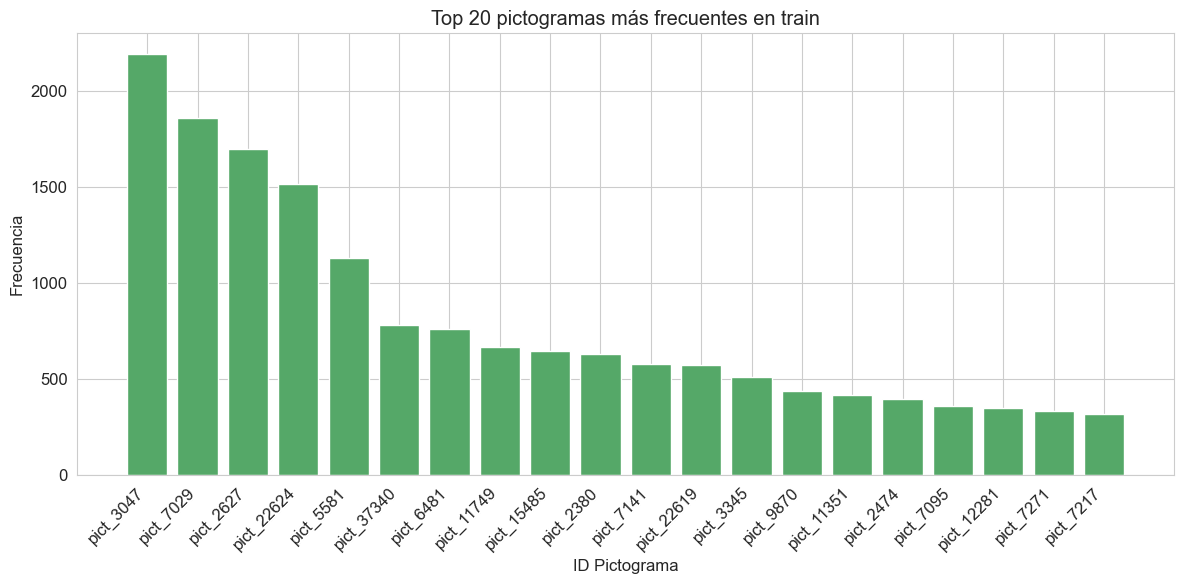

In [9]:
# ── Pictogramas más frecuentes ────────────────────────────────────
all_picts = []
for x in train_data:
    all_picts.extend(x["traduccion"].split())

pict_counter = Counter(all_picts)
top20 = pict_counter.most_common(20)

df_top = pd.DataFrame(top20, columns=["Pictograma", "Frecuencia"])

print("=== Top 20 pictogramas más frecuentes (train) ===")
print(df_top.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    [p for p, _ in top20],
    [c for _, c in top20],
    color="#55A868",
    edgecolor="white"
)

ax.set_title("Top 20 pictogramas más frecuentes en train")
ax.set_xlabel("ID Pictograma")
ax.set_ylabel("Frecuencia")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("top_pictogramas.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── Vocabulario y cobertura ───────────────────────────────────────
train_picts = set()
for x in train_data:
    train_picts.update(x["traduccion"].split())

test_picts = set()
for x in test_data:
    if "traduccion" in x:
        test_picts.update(x["traduccion"].split())

# Tokens fuera de vocabulario (no son pict_xxxx)
def count_oov(data, field="traduccion"):
    oov = set()
    for x in data:
        if field in x:
            for tok in x[field].split():
                if not tok.startswith("pict_"):
                    oov.add(tok)
    return oov

train_oov = count_oov(train_data)
test_oov = count_oov(test_data)

print(f"Vocabulario (pictogramas únicos):")
print(f" train: {len(train_picts):,} | test: {len(test_picts):,}")
print(f"\nTokens NO-pictograma (palabras textuales) en referencias:")
print(f" train OOV: {len(train_oov):,} | test OOV: {len(test_oov):,}")
print(f" Ejemplos de OOV en test: {list(test_oov)[:10]}")

Vocabulario (pictogramas únicos):
 train: 5,900 | test: 1,276

Tokens NO-pictograma (palabras textuales) en referencias:
 train OOV: 3,962 | test OOV: 0
 Ejemplos de OOV en test: []


# 4. Limpieza de datos

In [11]:
# ── Funciones de limpieza ─────────────────────────────────────────
def clean_sequence(seq_str):
    """Limpia una secuencia de pictogramas:
    - Normaliza espacios
    - Elimina tokens vacíos
    - Devuelve lista de tokens
    """
    if not seq_str or not isinstance(seq_str, str):
        return []
    
    tokens = seq_str.strip().split()
    
    # Quitar tokens vacíos o solo espacios
    tokens = [t.strip() for t in tokens if t.strip()]
    
    return tokens


def is_valid_pict_token(tok):
    """True si el token es un pict_ID válido."""
    return tok.startswith("pict_") and tok in valid_pict_ids


def sequence_coverage(tokens):
    """Porcentaje de tokens que son pictogramas válidos."""
    if not tokens:
        return 0.0
    
    valid = sum(1 for t in tokens if is_valid_pict_token(t))
    return valid / len(tokens)


# ── Auditoría de predicciones ─────────────────────────────────────
models = {
    "Modelo 1": model1_by_id,
    "Modelo 2": model2_by_id,
    "Modelo 3": model3_by_id,
    "Modelo 4": model4_by_id
}

audit_rows = []

for m_name, m_dict in models.items():
    pict_valid, pict_total, oov_count = 0, 0, 0
    n_empty = 0

    for sid in EVAL_IDS:
        tokens = clean_sequence(m_dict[sid]["output"])

        if len(tokens) == 0:
            n_empty += 1

        for tok in tokens:
            pict_total += 1
            if is_valid_pict_token(tok):
                pict_valid += 1
            else:
                oov_count += 1

    audit_rows.append({
        "Modelo": m_name,
        "Predicciones vacías": n_empty,
        "Tokens totales": pict_total,
        "pict_ID válidos": pict_valid,
        "Tokens OOV / texto": oov_count,
        "% Cobertura": round(100 * pict_valid / pict_total if pict_total else 0, 1)
    })

df_audit = pd.DataFrame(audit_rows)

print("=== Auditoría de predicciones ===")
print(df_audit.to_string(index=False))


=== Auditoría de predicciones ===
  Modelo  Predicciones vacías  Tokens totales  pict_ID válidos  Tokens OOV / texto  % Cobertura
Modelo 1                    0             201              189                  12         94.0
Modelo 2                    0             204              184                  20         90.2
Modelo 3                    0             204              204                   0        100.0
Modelo 4                    0             167              167                   0        100.0


In [12]:
# ── Auditoría de referencias (ground truth del test subset) ─────
ref_empty = 0
ref_oov_tokens = []
for sid in EVAL_IDS:
    ref_tokens = clean_sequence(test_by_id[sid]["traduccion"])
    if len(ref_tokens) == 0:
        ref_empty += 1
    for tok in ref_tokens:
        if not tok.startswith("pict_"):
            ref_oov_tokens.append(tok)
print(f"Referencias vacías: {ref_empty}")
print(f"Tokens OOV en referencias: {len(ref_oov_tokens)}")
print(f"Tokens OOV únicos: {len(set(ref_oov_tokens))}")
print(f"Ejemplos: {list(set(ref_oov_tokens))[:15]}")


Referencias vacías: 0
Tokens OOV en referencias: 0
Tokens OOV únicos: 0
Ejemplos: []


# 5. Métricas baseline: BLEU y chrF++

In [13]:
# ── Preparar hipótesis y referencias ─────────────────────────────
def prepare_sentences(model_dict, ref_dict, ids):
    """Retorna (hypotheses_str, references_str) como listas de strings."""
    hyps, refs = [], []
    for sid in ids:
        hyp = " ".join(clean_sequence(model_dict[sid]["output"]))
        ref = " ".join(clean_sequence(ref_dict[sid]["traduccion"]))
        hyps.append(hyp)
        refs.append(ref)
    return hyps, refs

# Instanciar métricas
bleu_metric = BLEU(effective_order=True)
chrf_metric = CHRF(word_order=2) # chrF++ (word_order=2)

metric_rows = []
for m_name, m_dict in models.items():
    hyps, refs = prepare_sentences(m_dict, test_by_id, EVAL_IDS)

    # BLEU espera: hypotheses, [references]
    bleu_score = bleu_metric.corpus_score(hyps, [refs])
    chrf_score = chrf_metric.corpus_score(hyps, [refs])

    metric_rows.append({
        "Modelo": m_name,
        "BLEU": round(bleu_score.score, 2),
        "chrF++": round(chrf_score.score, 2),
    })
    print(f"{m_name}: BLEU={bleu_score.score:.2f} chrF++={chrf_score.score:.2f}")

df_metrics = pd.DataFrame(metric_rows)
print("\n=== Tabla resumen métricas baseline ===")
print(df_metrics.to_string(index=False))


Modelo 1: BLEU=41.24 chrF++=55.73
Modelo 2: BLEU=29.68 chrF++=43.40
Modelo 3: BLEU=32.30 chrF++=48.75
Modelo 4: BLEU=30.14 chrF++=41.88

=== Tabla resumen métricas baseline ===
  Modelo  BLEU  chrF++
Modelo 1 41.24   55.73
Modelo 2 29.68   43.40
Modelo 3 32.30   48.75
Modelo 4 30.14   41.88


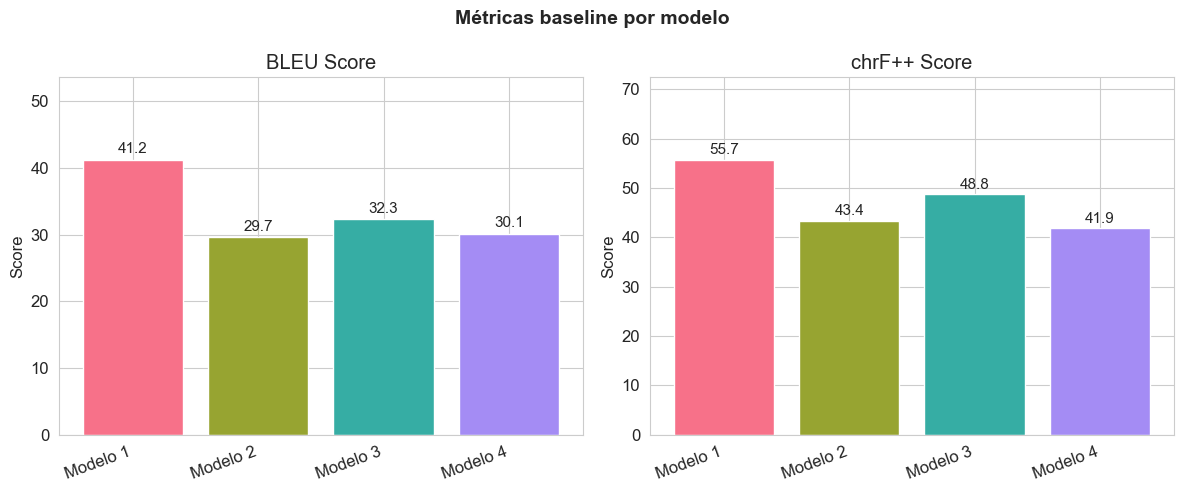

In [14]:
# ── Visualización de métricas baseline ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(df_metrics))
w = 0.5
colors = sns.color_palette("husl", 4)

for i, (col, title) in enumerate([("BLEU", "BLEU Score"), ("chrF++", "chrF++ Score")]):
    ax2 = axes[i]

    bars = ax2.bar(
        df_metrics["Modelo"],
        df_metrics[col],
        color=colors,
        edgecolor="white"
    )

    ax2.set_title(title)
    ax2.set_ylabel("Score")
    ax2.set_ylim(0, max(df_metrics[col]) * 1.3)

    # Etiquetas encima de las barras
    for bar in bars:
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")

plt.suptitle("Métricas baseline por modelo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("metricas_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# 6. Métricas semánticas: Concept F1 y Coverage Score

In [15]:
# ── Concept F1 ───────────────────────────────────────────────────
# Compara conjuntos de tokens (bag-of-pictograms) sin importar el orden

def concept_precision_recall_f1(hyp_tokens, ref_tokens):
    """Calcula P, R, F1 basado en conjuntos de pictogramas."""
    
    hyp_set = set(hyp_tokens)
    ref_set = set(ref_tokens)

    # Casos borde
    if len(hyp_set) == 0 and len(ref_set) == 0:
        return 1.0, 1.0, 1.0
    if len(hyp_set) == 0 or len(ref_set) == 0:
        return 0.0, 0.0, 0.0

    tp = len(hyp_set & ref_set)

    precision = tp / len(hyp_set)
    recall = tp / len(ref_set)

    # Evitar división por cero
    if (precision + recall) == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1


# ── Concept F1 para cada modelo ───────────────────────────────────
semantic_rows = []

for m_name, m_dict in models.items():
    p_list, r_list, f1_list = [], [], []

    for sid in EVAL_IDS:
        hyp_tokens = clean_sequence(m_dict[sid]["output"])
        ref_tokens = clean_sequence(test_by_id[sid]["traduccion"])

        p, r, f1 = concept_precision_recall_f1(hyp_tokens, ref_tokens)

        p_list.append(p)
        r_list.append(r)
        f1_list.append(f1)

    semantic_rows.append({
        "Modelo": m_name,
        "Concept P": round(np.mean(p_list) * 100, 2),
        "Concept R": round(np.mean(r_list) * 100, 2),
        "Concept F1": round(np.mean(f1_list) * 100, 2),
    })

df_semantic = pd.DataFrame(semantic_rows)

print("=== Concept F1 por modelo ===")
print(df_semantic.to_string(index=False))

=== Concept F1 por modelo ===
  Modelo  Concept P  Concept R  Concept F1
Modelo 1      42.34      48.77       44.49
Modelo 2      24.86      27.20       25.49
Modelo 3      35.00      40.07       36.62
Modelo 4      30.03      30.60       28.88


In [16]:
# ── Coverage Score ───────────────────────────────────────────────
# ¿Qué porcentaje de pictogramas de la referencia aparece en la predicción?

def coverage_score(hyp_tokens, ref_tokens):
    """Fracción de picts de referencia cubiertos por la predicción."""
    
    if not ref_tokens:
        return 1.0
    
    hyp_set = set(hyp_tokens)
    covered = sum(1 for t in ref_tokens if t in hyp_set)
    
    return covered / len(ref_tokens)


# ── Calcular coverage por modelo ──────────────────────────────────
coverage_rows = []

for m_name, m_dict in models.items():
    cov_list = []

    for sid in EVAL_IDS:
        hyp_tokens = clean_sequence(m_dict[sid]["output"])
        ref_tokens = clean_sequence(test_by_id[sid]["traduccion"])

        cov_list.append(coverage_score(hyp_tokens, ref_tokens))

    coverage_rows.append({
        "Modelo": m_name,
        "Coverage": round(np.mean(cov_list) * 100, 2)
    })

df_cov = pd.DataFrame(coverage_rows)

print("=== Coverage Score por modelo ===")
print(df_cov.to_string(index=False))


# ── Tabla consolidada ─────────────────────────────────────────────
df_all_metrics = (
    df_metrics
    .merge(df_semantic, on="Modelo")
    .merge(df_cov, on="Modelo")
)

print("\n=== TABLA CONSOLIDADA DE MÉTRICAS ===")
print(df_all_metrics.to_string(index=False))

=== Coverage Score por modelo ===
  Modelo  Coverage
Modelo 1     48.77
Modelo 2     27.20
Modelo 3     40.07
Modelo 4     30.60

=== TABLA CONSOLIDADA DE MÉTRICAS ===
  Modelo  BLEU  chrF++  Concept P  Concept R  Concept F1  Coverage
Modelo 1 41.24   55.73      42.34      48.77       44.49     48.77
Modelo 2 29.68   43.40      24.86      27.20       25.49     27.20
Modelo 3 32.30   48.75      35.00      40.07       36.62     40.07
Modelo 4 30.14   41.88      30.03      30.60       28.88     30.60


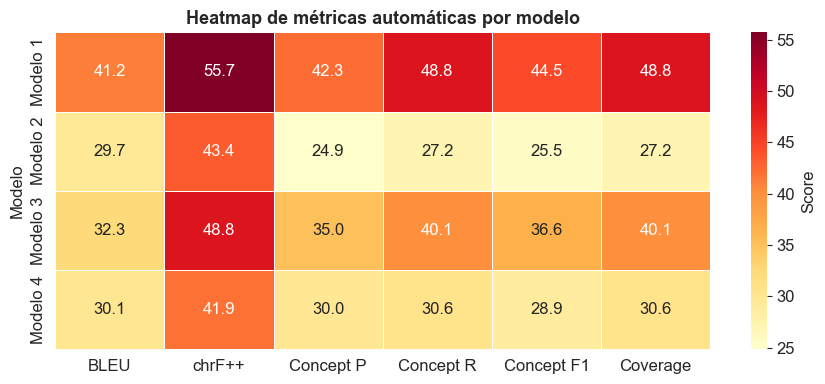

In [17]:
# ── Heatmap de métricas ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

metric_cols = ["BLEU", "chrF++", "Concept P", "Concept R", "Concept F1", "Coverage"]

heat_data = df_all_metrics.set_index("Modelo")[metric_cols]

sns.heatmap(
    heat_data,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Score"}
)

ax.set_title(
    "Heatmap de métricas automáticas por modelo",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("heatmap_metricas.png", dpi=150, bbox_inches="tight")
plt.show()

# 7. Análisis de concordancia entre evaluadores
Usamos Krippendorff's Alpha para medir el acuerdo entre los 8 evaluadores humanos.
- α > 0.8: acuerdo fuerte
- α 0.6–0.8: acuerdo moderado
- α < 0.6: acuerdo débil

In [18]:
# ── Construir matriz de evaluaciones humanas ─────────────────────
# Estructura: para cada (sentence_id, model), tenemos 8 scores

def parse_human_scores(evaluations, model_key="A_fiable"):
    """
    Extrae los scores de un modelo específico de todos los evaluadores.
    model_key: 'A_fiable', 'B_fiable', 'C_fiable', 'D_fiable'
    Retorna DataFrame: filas=evaluadores, columnas=sentence_ids
    """
    data = {}

    for ev in evaluations:
        user = ev["usuario"]
        scores = {}

        for resp in ev["respuestas"]:
            sid = resp["id"]
            ev_dict = resp["evaluacion"]

            if model_key in ev_dict:
                scores[sid] = ev_dict[model_key]

        data[user] = scores

    # filas = evaluadores, columnas = sentence_ids
    df = pd.DataFrame(data).T
    return df


# ── Matriz para cada modelo ───────────────────────────────────────
human_scores = {}

for mk, label in [
    ("A_fiable", "Modelo 1"),
    ("B_fiable", "Modelo 2"),
    ("C_fiable", "Modelo 3"),
    ("D_fiable", "Modelo 4")
]:
    human_scores[label] = parse_human_scores(evaluations, mk)


# ── Vista general ────────────────────────────────────────────────
print("=== Scores humanos – Modelo 1 (primeras 5 frases, primeros 3 evaluadores) ===")

sample_df = human_scores["Modelo 1"].iloc[:3, :5]

print(sample_df.to_string())
print(f"\nDimensiones: {human_scores['Modelo 1'].shape}")

=== Scores humanos – Modelo 1 (primeras 5 frases, primeros 3 evaluadores) ===
                                 0    1    2    3    4
a.paredes.um@gmail.com         3.0  5.0  4.0  3.0  5.0
angela.mariategui@gmail.com    NaN  NaN  NaN  NaN  NaN
CUSIPAUCARALACANTARAGMAIL.COM  3.0  4.0  4.0  4.0  4.0

Dimensiones: (8, 50)


In [ ]:
# ── Krippendorff's Alpha ─────────────────────────────────────────
import krippendorff
alpha_rows = []
for label, df_h in human_scores.items():
    # krippendorff espera: rows=raters, cols=items (con NaN si falta)
    reliability_data = df_h.values.astype(float)
    alpha = krippendorff.alpha(reliability_data, level_of_measurement="ordinal")
    alpha_rows.append({"Modelo": label, "Krippendorff α": round(alpha, 4)})

df_alpha = pd.DataFrame(alpha_rows)
print("=== Acuerdo inter-anotador (Krippendorff α ordinal) ===")
print(df_alpha.to_string(index=False))

# Interpretación
for _, row in df_alpha.iterrows():
    a = row["Krippendorff α"]
    if a >= 0.8: interp = "Fuerte"
    elif a >= 0.6: interp = "Moderado"
    else: interp = "Débil"
    print(f" {row['Modelo']}: {interp} (α={a})")

=== Acuerdo inter-anotador (Krippendorff α ordinal) ===
  Modelo  Krippendorff α
Modelo 1          0.1136
Modelo 2          0.3598
Modelo 3          0.2208
Modelo 4          0.1661
 Modelo 1: ❌ Débil (α=0.1136)
 Modelo 2: ❌ Débil (α=0.3598)
 Modelo 3: ❌ Débil (α=0.2208)
 Modelo 4: ❌ Débil (α=0.1661)


=== Scores humanos promedio ===
  Modelo  Score humano μ  Score humano σ
Modelo 1           3.251           1.460
Modelo 2           2.277           1.446
Modelo 3           2.940           1.510
Modelo 4           2.529           1.431


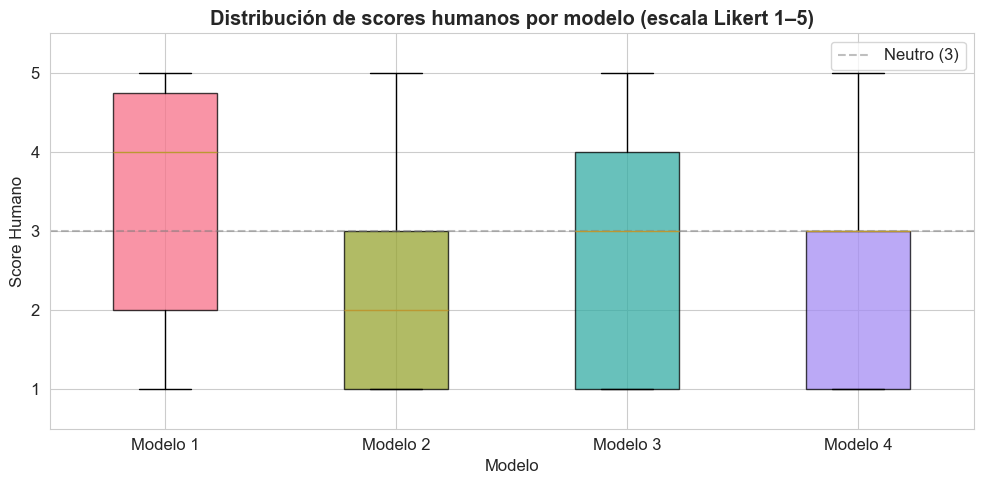

In [20]:
# ── Score humano promedio por modelo ─────────────────────────────
human_mean_rows = []

for label, df_h in human_scores.items():
    mean_score = df_h.values.flatten()
    mean_score = mean_score[~np.isnan(mean_score)]

    human_mean_rows.append({
        "Modelo": label,
        "Score humano μ": round(np.mean(mean_score), 3),
        "Score humano σ": round(np.std(mean_score), 3),
    })

df_human_mean = pd.DataFrame(human_mean_rows)

print("=== Scores humanos promedio ===")
print(df_human_mean.to_string(index=False))


# ── Boxplot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = []
plot_labels = []

for label, df_h in human_scores.items():
    vals = df_h.values.flatten()
    vals = vals[~np.isnan(vals)]

    plot_data.append(vals)
    plot_labels.append(label)

bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True)

colors_bp = sns.color_palette("husl", 4)

for patch, color in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title(
    "Distribución de scores humanos por modelo (escala Likert 1–5)",
    fontweight="bold"
)

ax.set_ylabel("Score Humano")
ax.set_xlabel("Modelo")
ax.set_ylim(0.5, 5.5)

ax.axhline(3, color="gray", linestyle="--", alpha=0.5, label="Neutro (3)")
ax.legend()

plt.tight_layout()
plt.savefig("boxplot_scores_humanos.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# ── Concordancia: ¿Cuándo los evaluadores NO están de acuerdo? ────
print("=== Análisis de desacuerdo (varianza por frase) ===\n")
disagreement_rows = []
for label, df_h in human_scores.items():
    variances = df_h.var(axis=0) # varianza entre evaluadores por frase
    high_var = variances[variances > 1.5].sort_values(ascending=False)
    disagreement_rows.append({
        "Modelo": label,
        "Frases con alta varianza (>1.5)": len(high_var),
        "Varianza media": round(variances.mean(), 3),
        "ID mayor desacuerdo": high_var.index[0] if len(high_var) > 0 else "—",
    })

df_disagree = pd.DataFrame(disagreement_rows)
print(df_disagree.to_string(index=False))

=== Análisis de desacuerdo (varianza por frase) ===

  Modelo  Frases con alta varianza (>1.5)  Varianza media  ID mayor desacuerdo
Modelo 1                               34           1.931                   16
Modelo 2                               19           1.315                   16
Modelo 3                               30           1.810                   11
Modelo 4                               28           1.713                    9


# 8. Correlación: métricas automáticas vs. evaluación humana
Calculamos correlación de Pearson (lineal) y Spearman (rango) entre cada métrica automática y el score humano promedio.


In [ ]:
# ── Construir DataFrame per-sample para correlación ──────────────
def compute_per_sample_metrics(model_dict, ref_dict, ids):
    """Devuelve DataFrame con una fila por ejemplo evaluado."""
    rows = []
    bleu_s = BLEU(effective_order=True)
    chrf_s = CHRF(word_order=2)

    for sid in ids:
        hyp_tokens = clean_sequence(model_dict[sid]["output"])
        ref_tokens = clean_sequence(ref_dict[sid]["traduccion"])
        hyp_str = " ".join(hyp_tokens)
        ref_str = " ".join(ref_tokens)

        # BLEU (sentence-level)
        bleu_val = bleu_s.sentence_score(hyp_str, [ref_str]).score
        # chrF++
        chrf_val = chrf_s.sentence_score(hyp_str, [ref_str]).score
        # Concept F1
        p, r, f1 = concept_precision_recall_f1(hyp_tokens, ref_tokens)
        # Coverage
        cov = coverage_score(hyp_tokens, ref_tokens)
        rows.append({
            "id": sid,
            "BLEU": bleu_val,
            "chrF++": chrf_val,
            "Concept_F1": f1 * 100,
            "Coverage": cov * 100,
        })
    return pd.DataFrame(rows).set_index("id")

# Construir tablas per-sample para cada modelo
per_sample = {
    "Modelo 1": compute_per_sample_metrics(model1_by_id, test_by_id, EVAL_IDS),
    "Modelo 2": compute_per_sample_metrics(model2_by_id, test_by_id, EVAL_IDS),
    "Modelo 3": compute_per_sample_metrics(model3_by_id, test_by_id, EVAL_IDS),
    "Modelo 4": compute_per_sample_metrics(model4_by_id, test_by_id, EVAL_IDS),
}

print("Métricas per-sample calculadas")
print(per_sample["Modelo 1"].head())


Métricas per-sample calculadas ✅
         BLEU     chrF++  Concept_F1   Coverage
id                                             
0    9.578464  25.046951    0.000000   0.000000
1   11.868405  22.664027    0.000000   0.000000
2   62.444517  77.764304   66.666667  80.000000
3   26.658377  55.150689   50.000000  66.666667
4   55.032121  39.858717    0.000000   0.000000


In [23]:
# ── Score humano promedio per-sample ─────────────────────────────

def human_mean_per_sample(df_human):
    """Score medio entre evaluadores para cada frase."""
    return df_human.mean(axis=0) # serie indexada por sentence_id

human_mean_sample = {
    label: human_mean_per_sample(df_h)
    for label, df_h in human_scores.items()
}

# ── Calcular correlaciones ────────────────────────────────────────
corr_rows = []
for model_label in ["Modelo 1", "Modelo 2", "Modelo 3", "Modelo 4"]:
    metrics_df = per_sample[model_label]
    h_mean = human_mean_sample[model_label]

    # Alinear por id
    common_ids = metrics_df.index.intersection(h_mean.index)
    h_vals = h_mean.loc[common_ids].values

    for metric_col in ["BLEU", "chrF++", "Concept_F1", "Coverage"]:
        m_vals = metrics_df.loc[common_ids, metric_col].values

        # Quitar NaN
        mask = ~(np.isnan(m_vals) | np.isnan(h_vals))
        m_clean = m_vals[mask]
        h_clean = h_vals[mask]

        if len(m_clean) < 3:
            continue

        pearson_r, pearson_p = pearsonr(m_clean, h_clean)
        spearman_r, spearman_p = spearmanr(m_clean, h_clean)

        corr_rows.append({
            "Modelo": model_label,
            "Métrica": metric_col,
            "Pearson r": round(pearson_r, 4),
            "Pearson p": round(pearson_p, 4),
            "Spearman r": round(spearman_r, 4),
            "Spearman p": round(spearman_p, 4),
            "N": int(mask.sum()),
        })
        
df_corr = pd.DataFrame(corr_rows)
print("=== Correlación: métricas automáticas vs. score humano ===")
print(df_corr.to_string(index=False))

=== Correlación: métricas automáticas vs. score humano ===
  Modelo    Métrica  Pearson r  Pearson p  Spearman r  Spearman p  N
Modelo 1       BLEU     0.2078     0.1476      0.1594      0.2690 50
Modelo 1     chrF++     0.1277     0.3770      0.0917      0.5266 50
Modelo 1 Concept_F1     0.0729     0.6151      0.0334      0.8181 50
Modelo 1   Coverage     0.0827     0.5680      0.0837      0.5635 50
Modelo 2       BLEU     0.2536     0.0755      0.2363      0.0985 50
Modelo 2     chrF++     0.1501     0.2982      0.1102      0.4462 50
Modelo 2 Concept_F1     0.3404     0.0156      0.3196      0.0237 50
Modelo 2   Coverage     0.3085     0.0293      0.2915      0.0400 50
Modelo 3       BLEU     0.2691     0.0588      0.1710      0.2352 50
Modelo 3     chrF++     0.2059     0.1514      0.0543      0.7079 50
Modelo 3 Concept_F1     0.1938     0.1774      0.0687      0.6356 50
Modelo 3   Coverage     0.1436     0.3198      0.0292      0.8405 50
Modelo 4       BLEU     0.0066     0.9637   

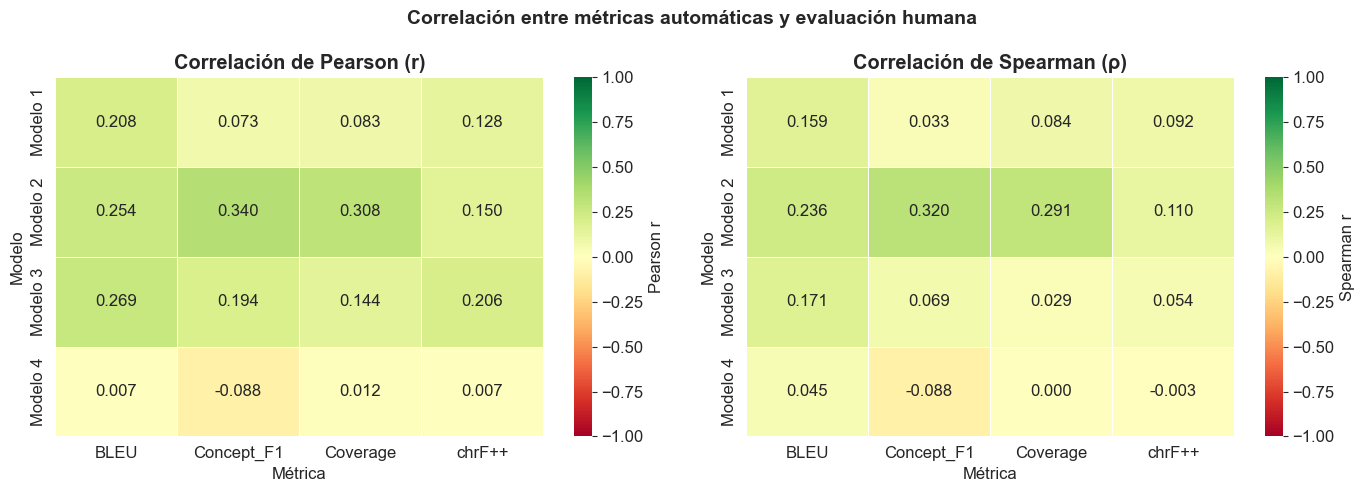

In [24]:
# ── Heatmap de correlaciones ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, corr_col, title in [
    (axes[0], "Pearson r", "Correlación de Pearson (r)"),
    (axes[1], "Spearman r", "Correlación de Spearman (ρ)"),
]:
    pivot = df_corr.pivot(index="Modelo", columns="Métrica", values=corr_col)

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": corr_col}
    )

    ax.set_title(title, fontweight="bold")


plt.suptitle(
    "Correlación entre métricas automáticas y evaluación humana",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("correlacion_metricas.png", dpi=150, bbox_inches="tight")
plt.show()

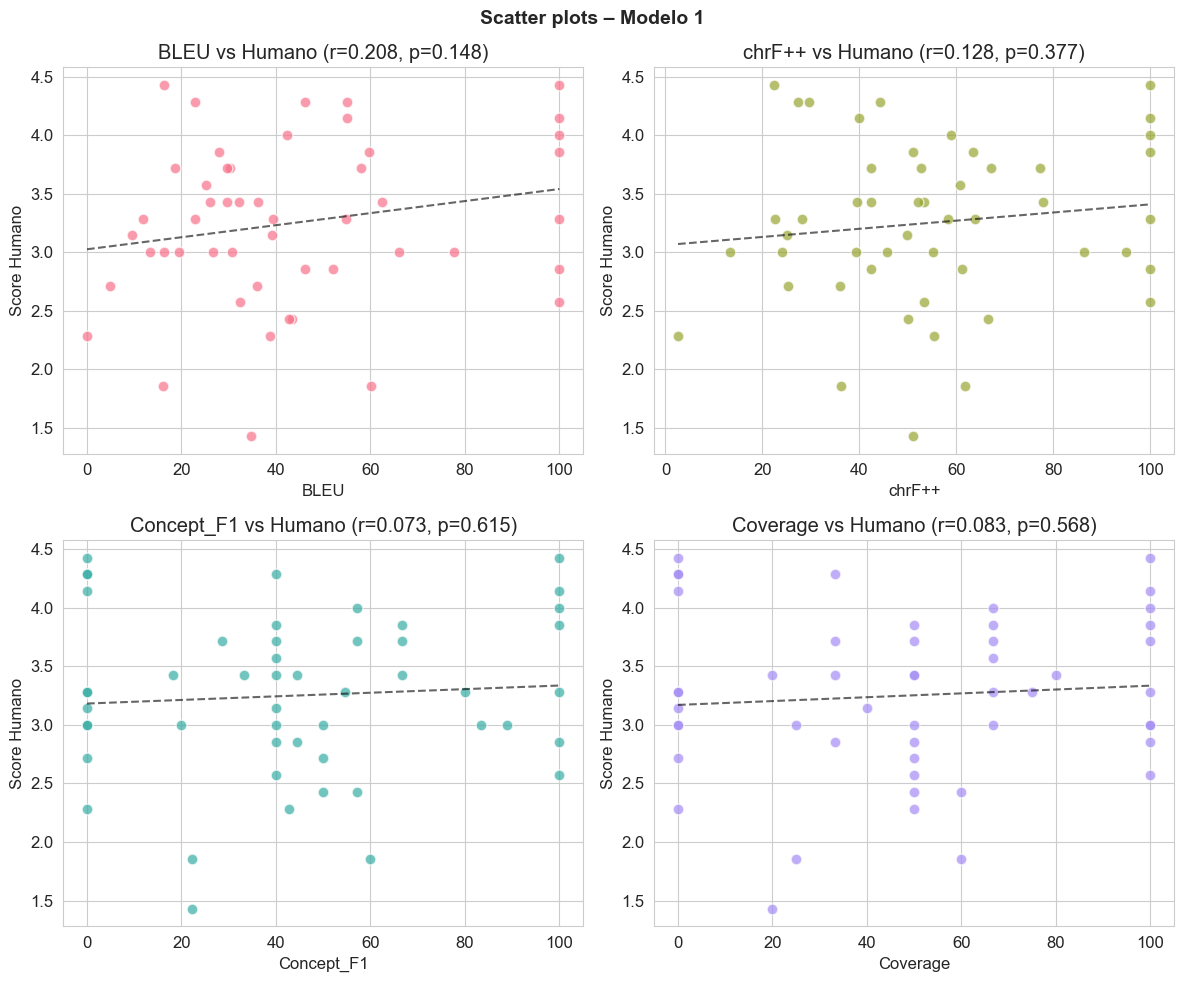

In [25]:
# ── Scatter plots: mejor vs peor métrica correlacionada ──────────
# (usa el modelo con más varianza para visualización)

target_model = "Modelo 1"
df_m = per_sample[target_model]
h_m = human_mean_sample[target_model]
common = df_m.index.intersection(h_m.index)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics = ["BLEU", "chrF++", "Concept_F1", "Coverage"]
colors_sc = sns.color_palette("husl", 4)

for ax, metric, color in zip(axes.flat, metrics, colors_sc):
    x = df_m.loc[common, metric].values
    y = h_m.loc[common].values
    mask = ~(np.isnan(x) | np.isnan(y))
    r, p = pearsonr(x[mask], y[mask])
    ax.scatter(x[mask], y[mask], color=color, alpha=0.7, edgecolors="white", s=60)
    # línea de tendencia
    z = np.polyfit(x[mask], y[mask], 1)
    pf = np.poly1d(z)
    xs = np.linspace(x[mask].min(), x[mask].max(), 100)
    ax.plot(xs, pf(xs), "k--", linewidth=1.5, alpha=0.6)
    ax.set_xlabel(metric)
    ax.set_ylabel("Score Humano")
    ax.set_title(f"{metric} vs Humano (r={r:.3f}, p={p:.3f})")

plt.suptitle(f"Scatter plots – {target_model}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("scatter_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

# 9. Resumen y próximos pasos

In [ ]:
# ── Tabla resumen ejecutiva ───────────────────────────────────────
print("=" * 65)
print(" RESUMEN SEMANA 4 – EVALUACIÓN SEMÁNTICA DE PICTOGRAMAS")
print("=" * 65)

print("\nDataset:")
print(f" Train: {len(train_data):,} | Test: {len(test_data):,} | Val: {len(val_data):,}")
print(f" 50 ejemplos evaluados con 4 modelos y 8 anotadores humanos\n")

print("Métricas automáticas:")
for _, row in df_all_metrics.iterrows():
    print(
        f" {row['Modelo']}: "
        f"BLEU={row['BLEU']:.1f} "
        f"chrF++={row['chrF++']:.1f} "
        f"ConceptF1={row['Concept F1']:.1f} "
        f"Coverage={row['Coverage']:.1f}"
    )

print("\nConcordancia inter-anotador (Krippendorff α):")
for _, row in df_alpha.iterrows():
    a = row["Krippendorff α"]
    interp = "Fuerte" if a >= 0.8 else ("Moderado" if a >= 0.6 else "Débil")
    print(f" {row['Modelo']}: α={a} ({interp})")

print("\nCorrelación más alta (Pearson):")
top_corr = df_corr.loc[df_corr["Pearson r"].abs().idxmax()]
print(f" {top_corr['Modelo']} – {top_corr['Métrica']}: r={top_corr['Pearson r']:.4f}")

print("\nPróximos pasos (Semana 5–7):")
print(" 1. LLM-Judge: diseñar prompts de evaluación estructurada")
print(" 2. Similaridad semántica con embeddings (LASER o LaBSE)")
print(" 3. Plataforma web de evaluación humana (FastAPI + React)")
print(" 4. Análisis de errores: BLEU alto vs. baja calidad")
print(" 5. Reporte técnico en formato paper")

 RESUMEN SEMANA 4 – EVALUACIÓN SEMÁNTICA DE PICTOGRAMAS

📊 Dataset:
 Train: 15,208 | Test: 973 | Val: 973
 50 ejemplos evaluados con 4 modelos y 8 anotadores humanos

📈 Métricas automáticas:
 Modelo 1: BLEU=41.2 chrF++=55.7 ConceptF1=44.5 Coverage=48.8
 Modelo 2: BLEU=29.7 chrF++=43.4 ConceptF1=25.5 Coverage=27.2
 Modelo 3: BLEU=32.3 chrF++=48.8 ConceptF1=36.6 Coverage=40.1
 Modelo 4: BLEU=30.1 chrF++=41.9 ConceptF1=28.9 Coverage=30.6

👥 Concordancia inter-anotador (Krippendorff α):
 Modelo 1: α=0.1136 (Débil)
 Modelo 2: α=0.3598 (Débil)
 Modelo 3: α=0.2208 (Débil)
 Modelo 4: α=0.1661 (Débil)

🔗 Correlación más alta (Pearson):
 Modelo 2 – Concept_F1: r=0.3404

🚀 Próximos pasos (Semana 5–7):
 1. LLM-Judge: diseñar prompts de evaluación estructurada
 2. Similaridad semántica con embeddings (LASER o LaBSE)
 3. Plataforma web de evaluación humana (FastAPI + React)
 4. Análisis de errores: BLEU alto vs. baja calidad
 5. Reporte técnico en formato paper


## 📁 Archivos generados

| 📄 Archivo                | 📝 Descripción                                      |
|--------------------------|----------------------------------------------------|
| `dist_longitudes.png`    | Histogramas de longitud de frases y pictogramas    |
| `top_pictogramas.png`    | Top 20 pictogramas más frecuentes                  |
| `metricas_baseline.png`  | BLEU y chrF++ por modelo                           |
| `heatmap_metricas.png`   | Todas las métricas en heatmap                      |
| `boxplot_scores_humanos.png` | Distribución de scores humanos                |
| `correlacion_metricas.png`   | Heatmaps de correlación Pearson/Spearman       |
| `scatter_correlacion.png`    | Scatter plots métrica vs humano                |